## **Projeto Final de Inteligência Artificial Probabilística**

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.estimators import HillClimbSearch,BIC
from pgmpy.inference import VariableElimination
from sklearn.naive_bayes import CategoricalNB
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from skopt.plots import plot_convergence
from scipy.stats import entropy
from sklearn.calibration import CalibratedClassifierCV
from collections import Counter

### Preparação e Limpeza dos Dados

In [73]:
df = pd.read_csv('dataset.csv')

df = df[[
    'ht_form',
    'at_form',
    'ht_attack',
    'at_attack',
    'h2h_dominance',
    'odds_favorite',
    'result'
]]

df = df.dropna().reset_index(drop=True)

for c in df.columns:
    df[c] = df[c].astype(str)

print("Total jogos:", len(df))

Total jogos: 5583


In [74]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['result']
)

print("Treino:", len(train_df))
print("Teste :", len(test_df))

Treino: 4466
Teste : 1117


# Parte 1: Redes Bayesianas

### 1. Construção de Estruturas e Avaliação de Desempenho

Knowledge Engineering (Modelo Manual)

In [75]:
model_manual = DiscreteBayesianNetwork([
    ('ht_form', 'result'),
    ('at_form', 'result'),
    ('ht_attack', 'result'),
    ('at_attack', 'result'),
    ('h2h_dominance', 'result'),
    ('odds_favorite', 'result')
])

model_manual.fit(train_df, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


Aprendizagem Computacional (Modelo Automático)

In [76]:
hc = HillClimbSearch(train_df)
best_model = hc.estimate(scoring_method=BIC(train_df))

model_auto = DiscreteBayesianNetwork(best_model.edges())
model_auto.fit(train_df, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


Naive Bayes (Baseline)

In [77]:
model_nb = DiscreteBayesianNetwork([
    ('result', 'ht_form'),
    ('result', 'at_form'),
    ('result', 'ht_attack'),
    ('result', 'at_attack'),
    ('result', 'h2h_dominance'),
    ('result', 'odds_favorite')
])

model_nb.fit(train_df, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


Avaliação

In [78]:
def evaluate_model(model, test_data, target='result'):
    infer = VariableElimination(model)

    y_true = []
    y_pred = []

    for _, row in test_data.iterrows():
        evidence = row.drop(target).to_dict()

        pred = infer.map_query(
            variables=[target],
            evidence=evidence,
            show_progress=False
        )[target]

        y_true.append(row[target])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=['H', 'D', 'A'])

    return acc, cm, y_true, y_pred

acc_manual, cm_manual, y_true_m, y_pred_m = evaluate_model(model_manual, test_df)
acc_auto, cm_auto, y_true_a, y_pred_a = evaluate_model(model_auto, test_df)
acc_nb, cm_nb, y_true_nb, y_pred_nb = evaluate_model(model_nb, test_df)

In [79]:
print("\n==============================")
print("MODELO MANUAL")
print("==============================")
print("Accuracy:", round(acc_manual, 4))
print("Confusion Matrix [H,D,A]:")
print(cm_manual)
print("\nClassification Report:")
print(classification_report(y_true_m, y_pred_m))

print("\n==============================")
print("MODELO AUTOMÁTICO")
print("==============================")
print("Accuracy:", round(acc_auto, 4))
print("Confusion Matrix [H,D,A]:")
print(cm_auto)
print("\nClassification Report:")
print(classification_report(y_true_a, y_pred_a))

print("\n==============================")
print("MODELO NAIVE BAYES")
print("==============================")
print("Accuracy:", round(acc_nb, 4))
print("Confusion Matrix [H,D,A]:")
print(cm_nb)
print("\nClassification Report:")
print(classification_report(y_true_nb, y_pred_nb))


MODELO MANUAL
Accuracy: 0.5166
Confusion Matrix [H,D,A]:
[[340  39 114]
 [141  41  99]
 [111  36 196]]

Classification Report:
              precision    recall  f1-score   support

           A       0.48      0.57      0.52       343
           D       0.35      0.15      0.21       281
           H       0.57      0.69      0.63       493

    accuracy                           0.52      1117
   macro avg       0.47      0.47      0.45      1117
weighted avg       0.49      0.52      0.49      1117


MODELO AUTOMÁTICO
Accuracy: 0.5524
Confusion Matrix [H,D,A]:
[[402   0  91]
 [167   0 114]
 [128   0 215]]

Classification Report:
              precision    recall  f1-score   support

           A       0.51      0.63      0.56       343
           D       0.00      0.00      0.00       281
           H       0.58      0.82      0.68       493

    accuracy                           0.55      1117
   macro avg       0.36      0.48      0.41      1117
weighted avg       0.41      0.55

c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

Gráficos

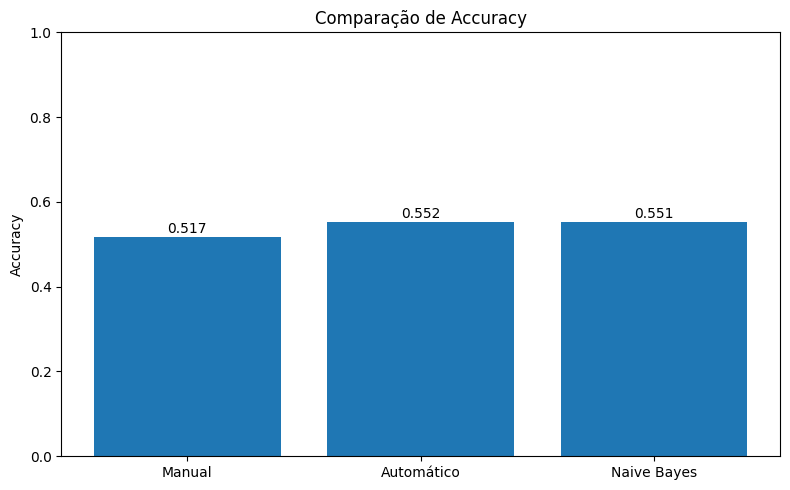

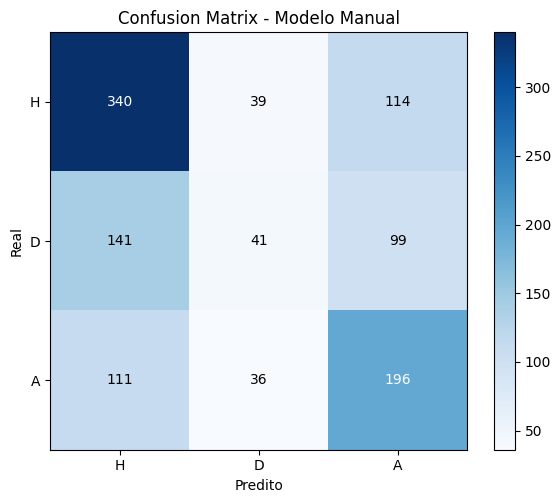

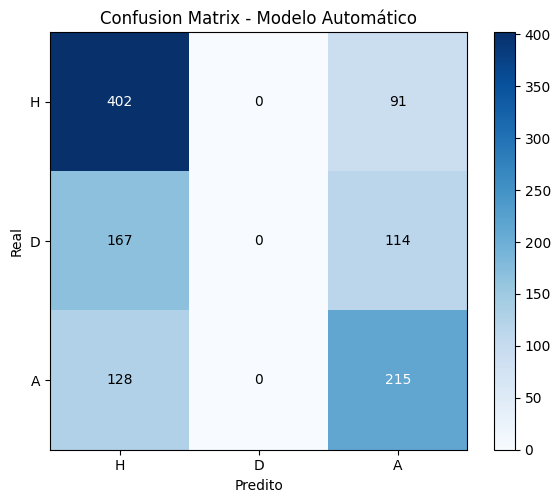

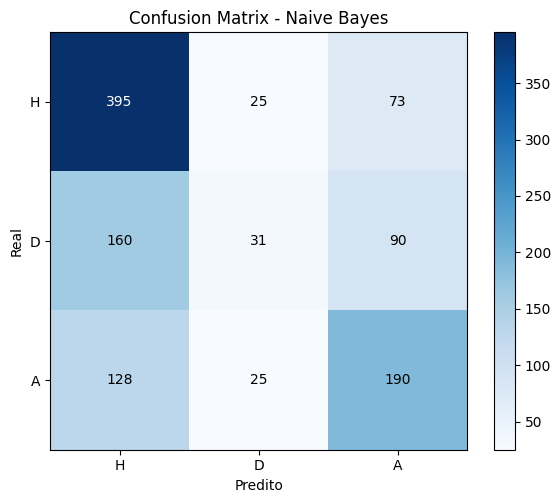

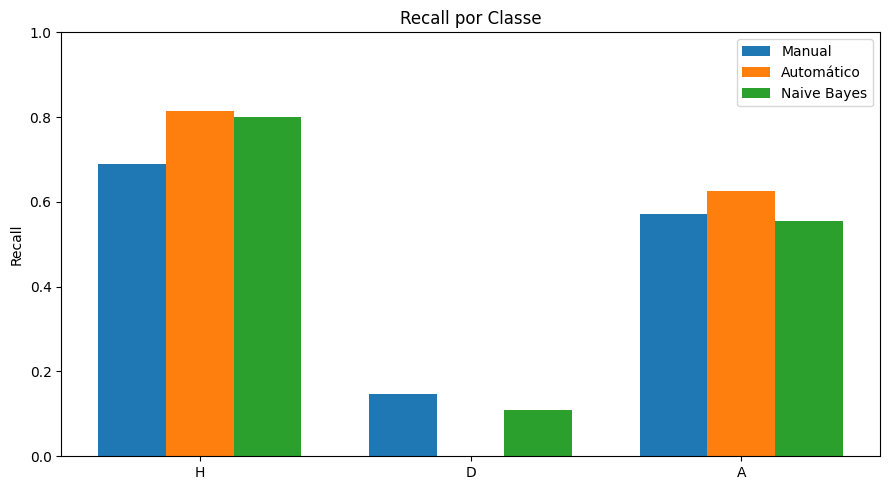

In [80]:
labels = ['H', 'D', 'A']

models = ['Manual', 'Automático', 'Naive Bayes']
accs = [acc_manual, acc_auto, acc_nb]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs)
plt.ylim(0, 1)
plt.title("Comparação de Accuracy")
plt.ylabel("Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.01, f"{y:.3f}", ha='center')

plt.tight_layout()
plt.show()

#-------------------------------------
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()
    plt.xticks(np.arange(len(labels)), labels)
    plt.yticks(np.arange(len(labels)), labels)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    thresh = cm.max() / 2
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_manual, "Confusion Matrix - Modelo Manual")
plot_confusion_matrix(cm_auto,   "Confusion Matrix - Modelo Automático")
plot_confusion_matrix(cm_nb,     "Confusion Matrix - Naive Bayes")


#-------------------------------------
recall_manual  = recall_score(y_true_m,  y_pred_m,  labels=['H', 'D', 'A'], average=None)
recall_auto    = recall_score(y_true_a,  y_pred_a,  labels=['H', 'D', 'A'], average=None)
recall_nb_vals = recall_score(y_true_nb, y_pred_nb, labels=['H', 'D', 'A'], average=None)

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - w, recall_manual,  width=w, label='Manual')
plt.bar(x,     recall_auto,    width=w, label='Automático')
plt.bar(x + w, recall_nb_vals, width=w, label='Naive Bayes')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Recall por Classe")
plt.legend()
plt.tight_layout()
plt.show()

### 2. Análise de Independências Condicionais (D-Separation)

In [81]:
def test_independence(model, X, Y, Z=None):
    if Z is None:
        Z = []
    indep = model.is_dconnected(X, Y, observed=Z)
    
    if indep:
        print(f"{X} e {Y} são DEPENDENTES dado {Z}")
    else:
        print(f"{X} e {Y} são INDEPENDENTES dado {Z}")

print("\n==============================")
print("D-SEPARATION (MODELO MANUAL)")
print("==============================")

test_independence(model_manual, 'ht_form', 'at_form')
test_independence(model_manual, 'ht_form', 'at_form', ['result'])

test_independence(model_manual, 'ht_attack', 'at_attack')
test_independence(model_manual, 'ht_attack', 'at_attack', ['result'])

test_independence(model_manual, 'h2h_dominance', 'odds_favorite')
test_independence(model_manual, 'h2h_dominance', 'odds_favorite', ['result'])


D-SEPARATION (MODELO MANUAL)
ht_form e at_form são INDEPENDENTES dado []
ht_form e at_form são DEPENDENTES dado ['result']
ht_attack e at_attack são INDEPENDENTES dado []
ht_attack e at_attack são DEPENDENTES dado ['result']
h2h_dominance e odds_favorite são INDEPENDENTES dado []
h2h_dominance e odds_favorite são DEPENDENTES dado ['result']


In [82]:
print("Edges do modelo automático:", model_auto.edges())

Edges do modelo automático: [('ht_form', 'ht_attack'), ('ht_form', 'h2h_dominance'), ('ht_form', 'odds_favorite'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('h2h_dominance', 'at_attack'), ('odds_favorite', 'at_attack'), ('odds_favorite', 'result'), ('odds_favorite', 'at_form'), ('at_attack', 'at_form')]


In [83]:
print("\n==============================")
print("D-SEPARATION (MODELO AUTOMÁTICO)")
print("==============================")

edges_auto = list(model_auto.edges())
print("Edges:", edges_auto)

nos = list(model_auto.nodes())
print("Nós:", nos)


D-SEPARATION (MODELO AUTOMÁTICO)
Edges: [('ht_form', 'ht_attack'), ('ht_form', 'h2h_dominance'), ('ht_form', 'odds_favorite'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('h2h_dominance', 'at_attack'), ('odds_favorite', 'at_attack'), ('odds_favorite', 'result'), ('odds_favorite', 'at_form'), ('at_attack', 'at_form')]
Nós: ['ht_form', 'ht_attack', 'h2h_dominance', 'odds_favorite', 'at_attack', 'at_form', 'result']


In [84]:
print("\n==============================")
print("D-SEPARATION (MODELO AUTOMÁTICO)")
print("==============================")

test_independence(model_auto, 'ht_form', 'at_form')
test_independence(model_auto, 'ht_form', 'at_form', ['h2h_dominance', 'odds_favorite'])

test_independence(model_auto, 'ht_attack', 'at_form')
test_independence(model_auto, 'ht_attack', 'at_form', ['h2h_dominance', 'odds_favorite'])

test_independence(model_auto, 'result', 'ht_form')
test_independence(model_auto, 'result', 'ht_form', ['h2h_dominance', 'odds_favorite'])

test_independence(model_auto, 'result', 'ht_attack')
test_independence(model_auto, 'result', 'ht_attack', ['h2h_dominance', 'odds_favorite'])


D-SEPARATION (MODELO AUTOMÁTICO)
ht_form e at_form são DEPENDENTES dado []
ht_form e at_form são INDEPENDENTES dado ['h2h_dominance', 'odds_favorite']
ht_attack e at_form são DEPENDENTES dado []
ht_attack e at_form são INDEPENDENTES dado ['h2h_dominance', 'odds_favorite']
result e ht_form são DEPENDENTES dado []
result e ht_form são INDEPENDENTES dado ['h2h_dominance', 'odds_favorite']
result e ht_attack são DEPENDENTES dado []
result e ht_attack são INDEPENDENTES dado ['h2h_dominance', 'odds_favorite']


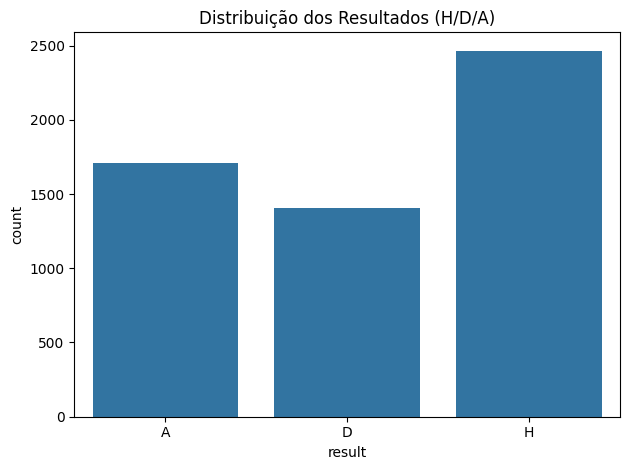

In [85]:
sns.countplot(x='result', data=df)
plt.title("Distribuição dos Resultados (H/D/A)")
plt.tight_layout()
plt.show()

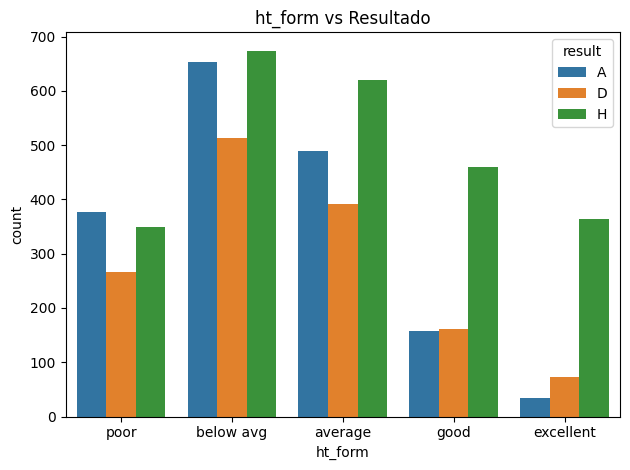

In [86]:
order = ['poor', 'below avg', 'average', 'good', 'excellent']

sns.countplot(x='ht_form', hue='result', data=df, order=order)
plt.title("ht_form vs Resultado")
plt.tight_layout()
plt.show()

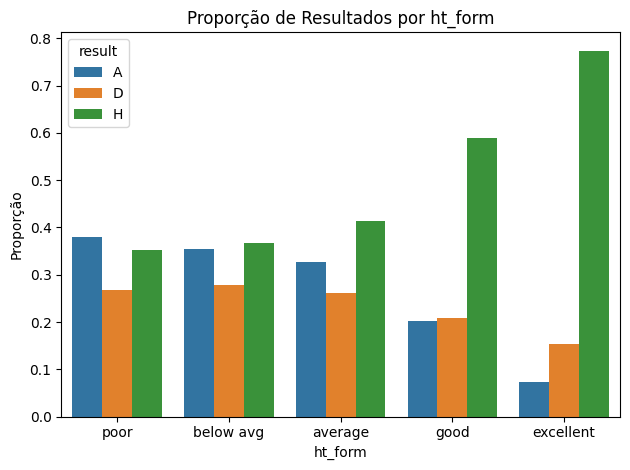

In [87]:
prop_df = (
    df.groupby(['ht_form', 'result'])
    .size()
    .reset_index(name='count')
)

prop_df['total'] = prop_df.groupby('ht_form')['count'].transform('sum')
prop_df['proportion'] = prop_df['count'] / prop_df['total']

sns.barplot(x='ht_form', y='proportion', hue='result', data=prop_df,
            order=order)

plt.title("Proporção de Resultados por ht_form")
plt.ylabel("Proporção")
plt.tight_layout()
plt.show()

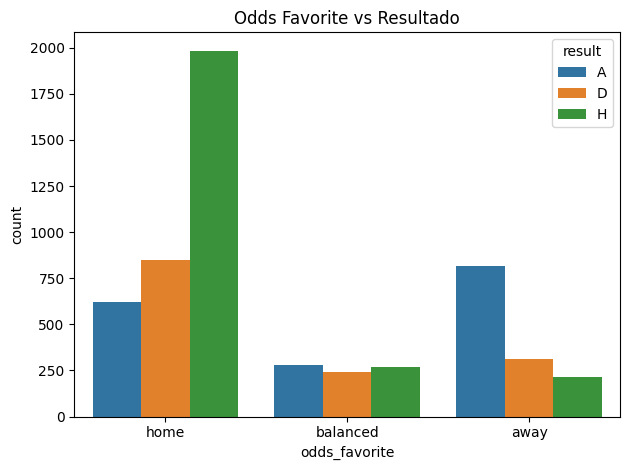

In [88]:
sns.countplot(x='odds_favorite', hue='result', data=df)
plt.title("Odds Favorite vs Resultado")
plt.tight_layout()
plt.show()

### 3. Aprendizagem de Parâmetros

In [89]:
model_manual_mle = model_manual.copy()
model_manual_mle.fit(train_df, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


In [90]:
model_manual_bayes = model_manual.copy()
model_manual_bayes.fit(
    train_df,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ht_form': 'C', 'at_form': 'C', 'ht_attack': 'C', 'at_attack': 'C', 'h2h_dominance': 'C', 'odds_favorite': 'C', 'result': 'C'}


In [91]:
acc_mle, cm_mle, y_true_mle, y_pred_mle = evaluate_model(model_manual_mle, test_df)
acc_bayes, cm_bayes, y_true_bayes, y_pred_bayes = evaluate_model(model_manual_bayes, test_df)

print("\n=== MLE ===")
print("Accuracy:", round(acc_mle, 4))
print(classification_report(y_true_mle, y_pred_mle))

print("\n=== BAYES ===")
print("Accuracy:", round(acc_bayes, 4))
print(classification_report(y_true_bayes, y_pred_bayes))


=== MLE ===
Accuracy: 0.5166
              precision    recall  f1-score   support

           A       0.48      0.57      0.52       343
           D       0.35      0.15      0.21       281
           H       0.57      0.69      0.63       493

    accuracy                           0.52      1117
   macro avg       0.47      0.47      0.45      1117
weighted avg       0.49      0.52      0.49      1117


=== BAYES ===
Accuracy: 0.5166
              precision    recall  f1-score   support

           A       0.48      0.57      0.52       343
           D       0.35      0.15      0.21       281
           H       0.57      0.69      0.63       493

    accuracy                           0.52      1117
   macro avg       0.47      0.47      0.45      1117
weighted avg       0.49      0.52      0.49      1117



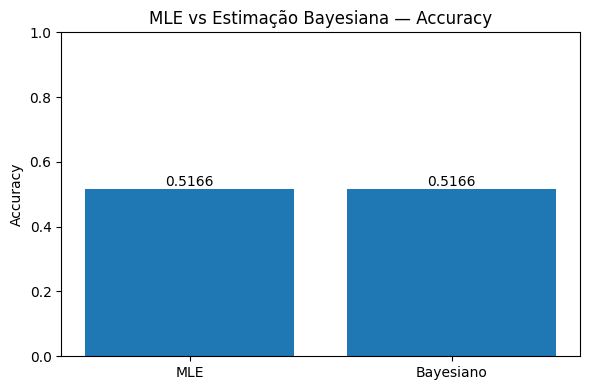

In [92]:
plt.figure(figsize=(6, 4))
bars = plt.bar(['MLE', 'Bayesiano'], [acc_mle, acc_bayes])
plt.ylim(0, 1)
plt.title("MLE vs Estimação Bayesiana — Accuracy")
plt.ylabel("Accuracy")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.01, f"{y:.4f}", ha='center')
plt.tight_layout()
plt.show()

In [93]:
print(model_manual_mle.get_cpds('result'))
print(model_manual_bayes.get_cpds('result'))

+---------------+-----+------------------------------+
| at_attack     | ... | at_attack(weak)              |
+---------------+-----+------------------------------+
| at_form       | ... | at_form(poor)                |
+---------------+-----+------------------------------+
| h2h_dominance | ... | h2h_dominance(home_dominant) |
+---------------+-----+------------------------------+
| ht_attack     | ... | ht_attack(weak)              |
+---------------+-----+------------------------------+
| ht_form       | ... | ht_form(poor)                |
+---------------+-----+------------------------------+
| odds_favorite | ... | odds_favorite(home)          |
+---------------+-----+------------------------------+
| result(A)     | ... | 0.3333333333333333           |
+---------------+-----+------------------------------+
| result(D)     | ... | 0.3333333333333333           |
+---------------+-----+------------------------------+
| result(H)     | ... | 0.3333333333333333           |
+---------

### 4. Inferências Probabilísticas e Análise de Cenários

In [94]:
infer = VariableElimination(model_manual)

print("\n==============================")
print("INFERÊNCIAS PROBABILÍSTICAS")
print("==============================")

# Q1 - Favoritismo e Forma
q1 = infer.query(
    variables=['result'],
    evidence={
        'ht_form': 'good',
        'odds_favorite': 'home'
    }
)
print("\nQ1 - Boa forma + favorito (casa)")
print(q1)


# Q2 - Cenário de Equilíbrio
q2 = infer.query(
    variables=['result'],
    evidence={
        'ht_form': 'average',
        'at_form': 'average'
    }
)
print("\nQ2 - Ambas forma média")
print(q2)


# Q3 - Inferência MAP
q3 = infer.map_query(
    variables=['result'],
    evidence={
        'h2h_dominance': 'home_dominant'
    }
)
print("\nQ3 - MAP com histórico favorável à casa")
print(q3)


# Q4 - Ataque vs Defesa
q4 = infer.query(
    variables=['result'],
    evidence={
        'ht_attack': 'strong',
        'at_attack': 'weak'
    }
)
print("\nQ4 - Ataque casa forte vs fora fraco")
print(q4)


# Q5 - A Equipa da Casa em Desvantagem
q5 = infer.query(
    variables=['result'],
    evidence={
        'odds_favorite': 'away',
        'ht_form': 'poor'
    }
)
print("\nQ5 - Casa em má forma + não favorita")
print(q5)


# Q6 - Equilíbrio total
q6 = infer.query(
    variables=['result'],
    evidence={
        'ht_form': 'average',
        'at_form': 'average',
        'ht_attack': 'average',
        'at_attack': 'average'
    }
)
print("\nQ6 - Equipas totalmente equilibradas")
print(q6)


INFERÊNCIAS PROBABILÍSTICAS

Q1 - Boa forma + favorito (casa)
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.2375 |
+-----------+---------------+
| result(D) |        0.2727 |
+-----------+---------------+
| result(H) |        0.4898 |
+-----------+---------------+

Q2 - Ambas forma média
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.3410 |
+-----------+---------------+
| result(D) |        0.2963 |
+-----------+---------------+
| result(H) |        0.3627 |
+-----------+---------------+


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]


Q3 - MAP com histórico favorável à casa
{'result': 'H'}

Q4 - Ataque casa forte vs fora fraco
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.3119 |
+-----------+---------------+
| result(D) |        0.3226 |
+-----------+---------------+
| result(H) |        0.3655 |
+-----------+---------------+

Q5 - Casa em má forma + não favorita
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.4174 |
+-----------+---------------+
| result(D) |        0.3052 |
+-----------+---------------+
| result(H) |        0.2774 |
+-----------+---------------+

Q6 - Equipas totalmente equilibradas
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.4157 |
+-----------+---------------+
| result(D) |        0.2531 |
+-----------+---------------+
| result(H) |        0.3312 |
+-----------+---------------+


# PARTE 2: Classificação Probabilística, Calibração e Otimização
### 1. Implementação do Classificador Naive Bayes


In [95]:
df_nb = df.copy()

encoders = {}
for col in df_nb.columns:
    le = LabelEncoder()
    df_nb[col] = le.fit_transform(df_nb[col])
    encoders[col] = le

In [96]:
print("Classes de 'result':", list(encoders['result'].classes_))

Classes de 'result': ['A', 'D', 'H']


In [97]:
X = df_nb.drop('result', axis=1)
y = df_nb['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred)
cm_nb  = confusion_matrix(y_test, y_pred)

print("\nAccuracy:", round(acc_nb, 4))
print("\nConfusion Matrix:")
print(cm_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoders['result'].classes_))


Accuracy: 0.5515

Confusion Matrix:
[[190  25 128]
 [ 90  31 160]
 [ 73  25 395]]

Classification Report:
              precision    recall  f1-score   support

           A       0.54      0.55      0.55       343
           D       0.38      0.11      0.17       281
           H       0.58      0.80      0.67       493

    accuracy                           0.55      1117
   macro avg       0.50      0.49      0.46      1117
weighted avg       0.52      0.55      0.51      1117



In [99]:
probs = nb_model.predict_proba(X_test)
print("\nExemplo de probabilidades (primeiras 5):")
print(probs[:5])


Exemplo de probabilidades (primeiras 5):
[[0.00746855 0.07807017 0.91446128]
 [0.1225521  0.29192066 0.58552724]
 [0.76748326 0.19046122 0.04205552]
 [0.20513693 0.3374189  0.45744417]
 [0.00816085 0.05132708 0.94051207]]


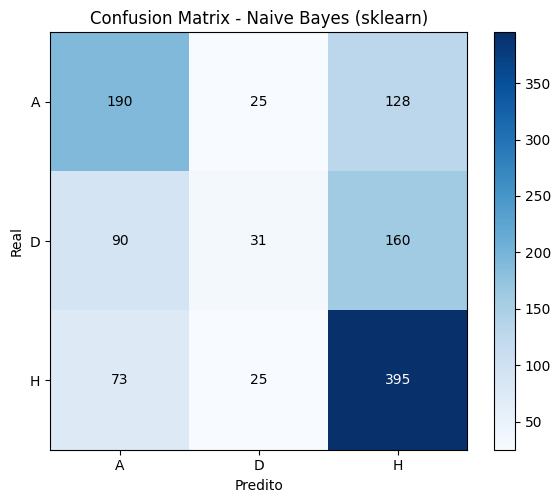

In [100]:
labels_nb = encoders['result'].classes_

plt.figure(figsize=(6, 5))
plt.imshow(cm_nb, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes (sklearn)")
plt.colorbar()
plt.xticks(np.arange(len(labels_nb)), labels_nb)
plt.yticks(np.arange(len(labels_nb)), labels_nb)
plt.xlabel("Predito")
plt.ylabel("Real")
thresh = cm_nb.max() / 2
for i in range(len(labels_nb)):
    for j in range(len(labels_nb)):
        plt.text(j, i, cm_nb[i, j], ha='center', va='center',
                 color='white' if cm_nb[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

### 2. Quantificação de Incerteza com Conformal Prediction

In [101]:
X_train2, X_calib, y_train2, y_calib = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

nb_model_cp = CategoricalNB()
nb_model_cp.fit(X_train2, y_train2)

CategoricalNB()

In [102]:
probs_calib = nb_model_cp.predict_proba(X_calib)

scores = np.array([
    1 - probs_calib[i][y_calib.iloc[i]]
    for i in range(len(y_calib))
])

Resultados da Calibração:


In [103]:
alpha = 0.1
q_hat = np.quantile(scores, 1 - alpha)
print(f"Quantil de calibração (q_hat): {q_hat:.4f}")

Quantil de calibração (q_hat): 0.9251


In [104]:
probs_test = nb_model_cp.predict_proba(X_test)

prediction_sets = [
    [c for c in range(probs_test.shape[1]) if (1 - probs_test[i][c]) <= q_hat]
    for i in range(len(probs_test))
]

In [105]:
coverage = np.mean([y_test.iloc[i] in prediction_sets[i] for i in range(len(y_test))])
avg_size = np.mean([len(s) for s in prediction_sets])

In [106]:
print(f"Coverage: {coverage:.4f}  (alvo >= {1 - alpha:.2f})")
print(f"Average set size: {avg_size:.4f}")

Coverage: 0.9158  (alvo >= 0.90)
Average set size: 2.3483


In [107]:
size_counts = Counter([len(s) for s in prediction_sets])
print("\nDistribuição do tamanho dos prediction sets:")
for size in sorted(size_counts):
    pct = size_counts[size] / len(prediction_sets) * 100
    print(f"  Tamanho {size}: {size_counts[size]} jogos ({pct:.1f}%)")


Distribuição do tamanho dos prediction sets:
  Tamanho 1: 212 jogos (19.0%)
  Tamanho 2: 304 jogos (27.2%)
  Tamanho 3: 601 jogos (53.8%)


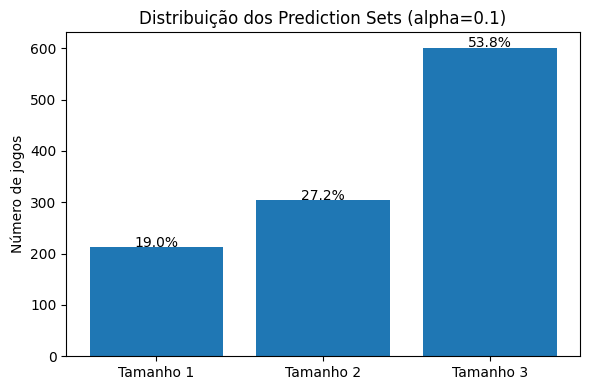

In [108]:
sizes = [len(s) for s in prediction_sets]
plt.figure(figsize=(6, 4))
plt.bar(sorted(size_counts.keys()),
        [size_counts[k] for k in sorted(size_counts.keys())])
plt.xticks(sorted(size_counts.keys()), [f"Tamanho {k}" for k in sorted(size_counts.keys())])
plt.ylabel("Número de jogos")
plt.title(f"Distribuição dos Prediction Sets (alpha={alpha})")
for k in sorted(size_counts.keys()):
    pct = size_counts[k] / len(prediction_sets) * 100
    plt.text(k, size_counts[k] + 1, f"{pct:.1f}%", ha='center')
plt.tight_layout()
plt.show()

### 3. Avaliação da Calibração do Modelo

In [109]:
probs_test_full = nb_model.predict_proba(X_test)

classes = encoders['result'].classes_

brier score e log loss

In [110]:
print("=== MÉTRICAS DE CALIBRAÇÃO ===\n")

brier_scores = {}
for i, cls in enumerate(classes):
    y_binary = (y_test == i).astype(int)
    bs = brier_score_loss(y_binary, probs_test_full[:, i])
    brier_scores[cls] = bs
    print(f"Brier Score ({cls}): {bs:.4f}")

print(f"\nBrier Score médio: {np.mean(list(brier_scores.values())):.4f}")
print(f"Log Loss: {log_loss(y_test, probs_test_full):.4f}")

=== MÉTRICAS DE CALIBRAÇÃO ===

Brier Score (A): 0.2014
Brier Score (D): 0.1869
Brier Score (H): 0.2150

Brier Score médio: 0.2011
Log Loss: 1.0704


diagramas de reliability

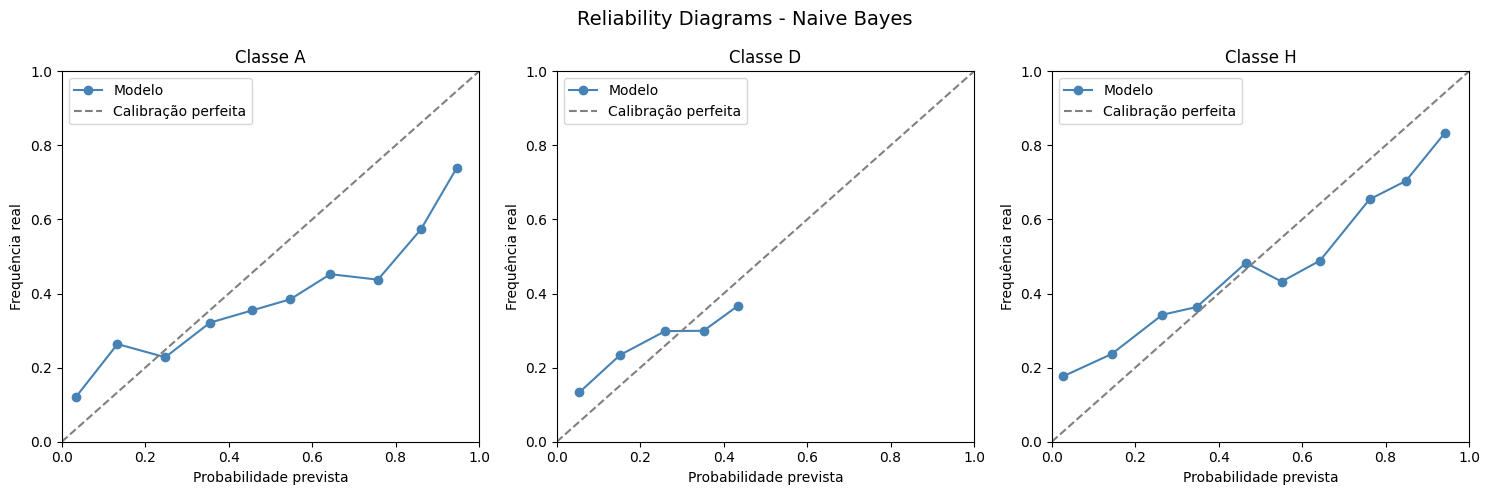

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Reliability Diagrams - Naive Bayes", fontsize=14)

for i, (cls, ax) in enumerate(zip(classes, axes)):
    y_binary = (y_test == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_binary, probs_test_full[:, i], n_bins=10)

    ax.plot(prob_pred, prob_true, marker='o', label='Modelo', color='steelblue')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
    ax.set_title(f"Classe {cls}")
    ax.set_xlabel("Probabilidade prevista")
    ax.set_ylabel("Frequência real")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

### 4. Otimização Bayesiana com Regressão Logística

pesquisa

In [112]:
search_space = {
    'C': Real(1e-3, 1e2, prior='log-uniform'),  # regularização
    'solver': Categorical(['lbfgs', 'saga']),
    'max_iter': Categorical([500, 1000, 2000])
}

BayesSearchCV faz cross-validation com Bayesian Optimization

In [113]:
bayes_search = BayesSearchCV(
    LogisticRegression(multi_class='multinomial'),
    search_space,
    n_iter=30,          
    cv=5,               
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print("=== BAYESIAN OPTIMIZATION ===\n")
print("Melhores hiperparâmetros:", bayes_search.best_params_)
print("Melhor accuracy (CV):", round(bayes_search.best_score_, 4))

y_pred_lr = bayes_search.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("\nAccuracy no teste:", round(acc_lr, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=encoders['result'].classes_))

=== BAYESIAN OPTIMIZATION ===

Melhores hiperparâmetros: OrderedDict({'C': 0.0034983593796458056, 'max_iter': 2000, 'solver': 'saga'})
Melhor accuracy (CV): 0.5515

Accuracy no teste: 0.5542

Classification Report:
              precision    recall  f1-score   support

           A       0.59      0.52      0.55       343
           D       0.00      0.00      0.00       281
           H       0.54      0.90      0.67       493

    accuracy                           0.55      1117
   macro avg       0.38      0.47      0.41      1117
weighted avg       0.42      0.55      0.47      1117



c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Utilizador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

comparação NB vs LR otimizada

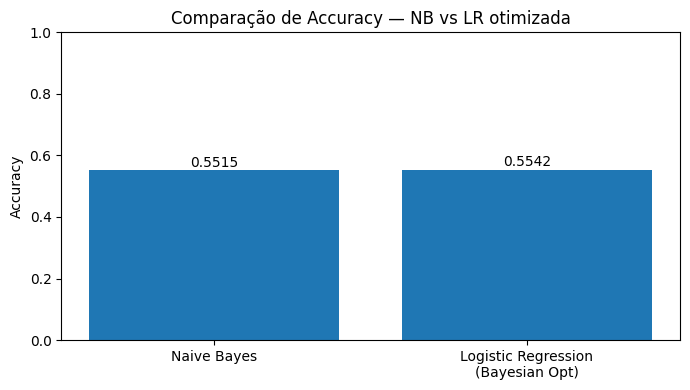

In [114]:
plt.figure(figsize=(7, 4))
bars = plt.bar(
    ['Naive Bayes', 'Logistic Regression\n(Bayesian Opt)'],
    [acc_nb, acc_lr]
)
plt.ylim(0, 1)
plt.title("Comparação de Accuracy — NB vs LR otimizada")
plt.ylabel("Accuracy")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.01, f"{y:.4f}", ha='center')
plt.tight_layout()
plt.show()

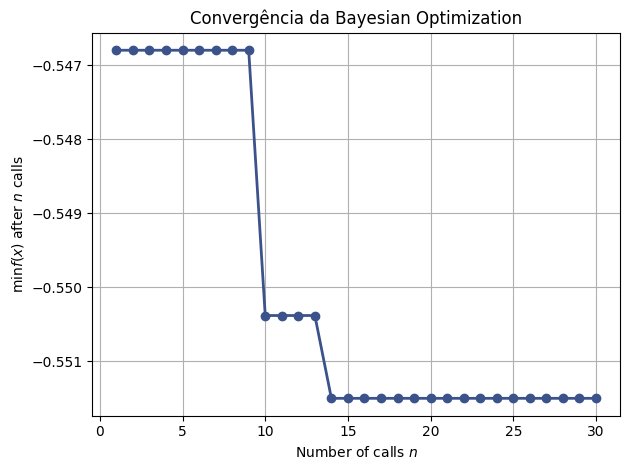

In [115]:
plot_convergence(bayes_search.optimizer_results_[0])
plt.title("Convergência da Bayesian Optimization")
plt.tight_layout()
plt.show()

# PARTE 3: Teoria de Utilidade e Tomada de Decisão

In [116]:
df_full = pd.read_csv('dataset.csv')
df_full = df_full.dropna(subset=['h_odds', 'd_odds', 'a_odds', 'result']).reset_index(drop=True)

df_nb_full = df_full[[
    'ht_form', 'at_form', 'ht_attack', 'at_attack',
    'h2h_dominance', 'odds_favorite', 'result',
    'h_odds', 'd_odds', 'a_odds'
]].dropna().reset_index(drop=True)

df_encoded = df_nb_full[[
    'ht_form', 'at_form', 'ht_attack', 'at_attack',
    'h2h_dominance', 'odds_favorite', 'result'
]].copy()

for col in df_encoded.columns:
    df_encoded[col] = encoders[col].transform(df_encoded[col])

X_full = df_encoded.drop('result', axis=1)
y_full = df_encoded['result']

# Split com mesmo random_state para consistência
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_full, y_full, df_nb_full.index,
    test_size=0.2, random_state=42, stratify=y_full
)
odds_test = df_nb_full.loc[idx_te, ['h_odds', 'd_odds', 'a_odds']].reset_index(drop=True)
y_te = y_te.reset_index(drop=True)

# Probabilidades implícitas das odds
# P_implícita = (1/odd) / soma(1/odd)
inv_odds = 1 / odds_test[['h_odds', 'd_odds', 'a_odds']].values
odds_probs = inv_odds / inv_odds.sum(axis=1, keepdims=True)

odds_probs_aligned = odds_probs[:, [2, 1, 0]]

# Probabilidades do modelo
model_probs = nb_model.predict_proba(X_te)

print("Classes do modelo:", encoders['result'].classes_)

Classes do modelo: ['A' 'D' 'H']


### 1. Avaliação de Utilidade e Divergência Face às Odds

Divergência entre modelo e odds (diferença absoluta por classe)

In [117]:
divergence = np.abs(model_probs - odds_probs_aligned)
mean_divergence = divergence.mean(axis=1)

print(f"\nDivergência média modelo vs odds: {mean_divergence.mean():.4f}")


Divergência média modelo vs odds: 0.1233


identificar jogos onde o modelo discorda mais das odds

In [118]:
threshold_divergence = np.percentile(mean_divergence, 75) 
high_disagreement = mean_divergence > threshold_divergence

print(f"Jogos com alta divergência (top 25%): {high_disagreement.sum()}")

Jogos com alta divergência (top 25%): 279


Accuracy do modelo nos jogos de alta divergência vs baixa divergência

In [119]:
y_pred_full = nb_model.predict(X_te)

acc_high_div = accuracy_score(y_te[high_disagreement], y_pred_full[high_disagreement])
acc_low_div  = accuracy_score(y_te[~high_disagreement], y_pred_full[~high_disagreement])

print(f"\nAccuracy — alta divergência:  {acc_high_div:.4f}")
print(f"Accuracy — baixa divergência: {acc_low_div:.4f}")



Accuracy — alta divergência:  0.5627
Accuracy — baixa divergência: 0.5477


Nos jogos de alta divergência: modelo ou odds é melhor?


In [120]:
odds_pred = np.argmax(odds_probs_aligned, axis=1)
acc_odds_high_div = accuracy_score(y_te[high_disagreement], odds_pred[high_disagreement])
acc_odds_low_div  = accuracy_score(y_te[~high_disagreement], odds_pred[~high_disagreement])

print(f"\nAccuracy odds — alta divergência:  {acc_odds_high_div:.4f}")
print(f"Accuracy odds — baixa divergência: {acc_odds_low_div:.4f}")


Accuracy odds — alta divergência:  0.5556
Accuracy odds — baixa divergência: 0.5549


Expected Value (EV) e Calibração Probabilística

In [121]:
calibrated_nb = CalibratedClassifierCV(
    nb_model,
    method='isotonic',
    cv=5
)

calibrated_nb.fit(X_train, y_train)

model_probs_cal = calibrated_nb.predict_proba(X_te)


EXPECTED VALUE (UTILITY)
Jogos com EV positivo: 1093
Percentagem de value bets: 97.85%
Accuracy nos jogos com EV positivo: 0.4776
EV médio máximo por jogo: 0.3112


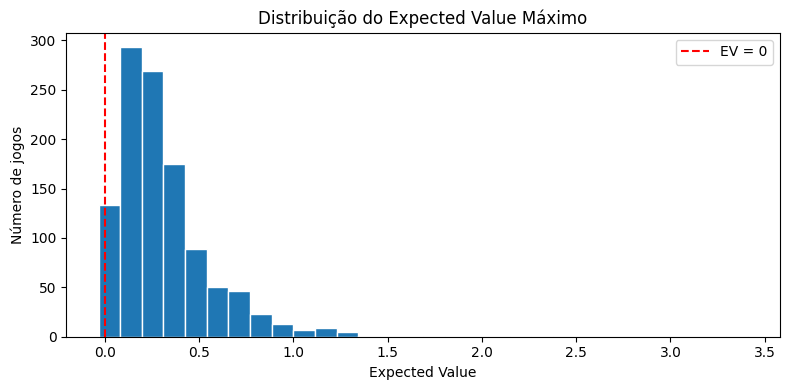

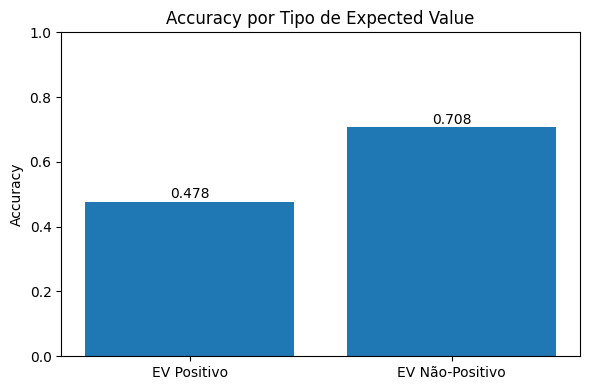

In [122]:
## Expected Value (Utility)

# EV(k) = P_model(k) * odds(k) - 1

ev_away = model_probs[:, 0] * odds_test['a_odds'].values - 1
ev_draw = model_probs[:, 1] * odds_test['d_odds'].values - 1
ev_home = model_probs[:, 2] * odds_test['h_odds'].values - 1

ev_matrix = np.column_stack([ev_away, ev_draw, ev_home])

best_ev = np.max(ev_matrix, axis=1)

best_ev_pred = np.argmax(ev_matrix, axis=1)

positive_ev = best_ev > 0

print("\n==============================")
print("EXPECTED VALUE (UTILITY)")
print("==============================")

print(f"Jogos com EV positivo: {positive_ev.sum()}")
print(f"Percentagem de value bets: {positive_ev.mean() * 100:.2f}%")

if positive_ev.sum() > 0:
    acc_ev = accuracy_score(
        y_te[positive_ev],
        best_ev_pred[positive_ev]
    )

    print(f"Accuracy nos jogos com EV positivo: {acc_ev:.4f}")

print(f"EV médio máximo por jogo: {best_ev.mean():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(best_ev, bins=30, edgecolor='white')

plt.axvline(
    0,
    color='red',
    linestyle='--',
    label='EV = 0'
)

plt.title("Distribuição do Expected Value Máximo")
plt.xlabel("Expected Value")
plt.ylabel("Número de jogos")
plt.legend()
plt.tight_layout()
plt.show()

if positive_ev.sum() > 0 and (~positive_ev).sum() > 0:

    acc_positive_ev = accuracy_score(
        y_te[positive_ev],
        best_ev_pred[positive_ev]
    )

    acc_negative_ev = accuracy_score(
        y_te[~positive_ev],
        best_ev_pred[~positive_ev]
    )

    plt.figure(figsize=(6, 4))

    bars = plt.bar(
        ['EV Positivo', 'EV Não-Positivo'],
        [acc_positive_ev, acc_negative_ev]
    )

    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Accuracy por Tipo de Expected Value")

    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            f"{y:.3f}",
            ha='center'
        )

    plt.tight_layout()
    plt.show()

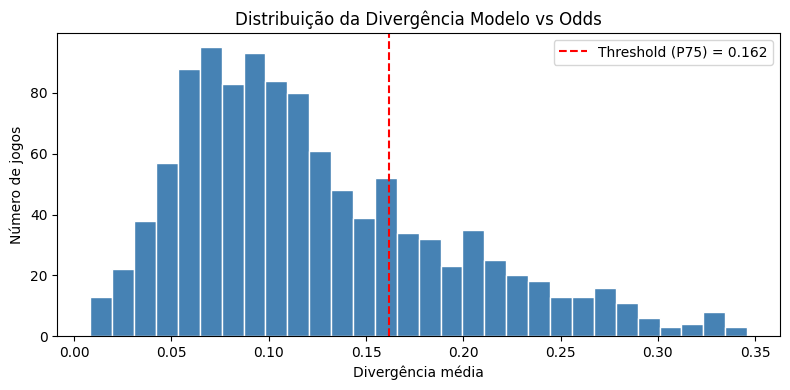

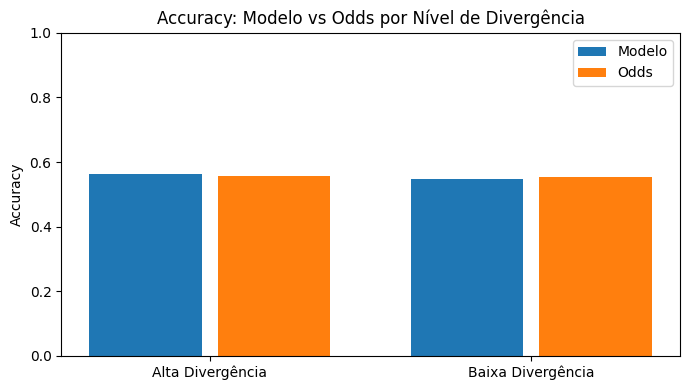

In [123]:
# distribuição da divergência
plt.figure(figsize=(8, 4))
plt.hist(mean_divergence, bins=30, color='steelblue', edgecolor='white')
plt.axvline(threshold_divergence, color='red', linestyle='--',
            label=f'Threshold (P75) = {threshold_divergence:.3f}')
plt.title("Distribuição da Divergência Modelo vs Odds")
plt.xlabel("Divergência média")
plt.ylabel("Número de jogos")
plt.legend()
plt.tight_layout()
plt.show()

# accuracy modelo vs odds por nível de divergência
plt.figure(figsize=(7, 4))
x = ['Alta Divergência', 'Baixa Divergência']
plt.bar(np.arange(2) - 0.2, [acc_high_div, acc_low_div], width=0.35, label='Modelo')
plt.bar(np.arange(2) + 0.2, [acc_odds_high_div, acc_odds_low_div], width=0.35, label='Odds')
plt.xticks(np.arange(2), x)
plt.ylim(0, 1)
plt.title("Accuracy: Modelo vs Odds por Nível de Divergência")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### 2. Quantificação de Incerteza e Estratégia de Reject Option

Medição de incerteza (Entropia)

In [124]:
entropies = np.array([entropy(model_probs[i]) for i in range(len(model_probs))])
max_entropy = entropy([1/3, 1/3, 1/3])  

print(f"\nEntropia máxima possível: {max_entropy:.4f}")
print(f"Entropia média do modelo: {entropies.mean():.4f}")


Entropia máxima possível: 1.0986
Entropia média do modelo: 0.7308


Impacto do Limiar de Rejeição (Threshold)

In [125]:
thresholds = np.linspace(0.5, max_entropy, 20)

results = []
for thresh in thresholds:
    confident = entropies <= thresh
    abstained = ~confident

    if confident.sum() == 0:
        continue

    acc_confident = accuracy_score(y_te[confident], y_pred_full[confident])
    acc_odds_all  = accuracy_score(y_te, odds_pred)

    if abstained.sum() > 0:
        n_correct = (y_te[confident] == y_pred_full[confident]).sum() + \
                    (y_te[abstained] == odds_pred[abstained]).sum()
        acc_combined = n_correct / len(y_te)
    else:
        acc_combined = acc_confident

    results.append({
        'threshold':      thresh,
        'n_confident':    confident.sum(),
        'pct_confident':  confident.mean() * 100,
        'acc_confident':  acc_confident,
        'acc_combined':   acc_combined,
        'acc_odds_all':   acc_odds_all
    })

results_df = pd.DataFrame(results)
print("\n=== REJECT OPTION — RESULTADOS ===")
print(results_df.to_string(index=False))


=== REJECT OPTION — RESULTADOS ===
 threshold  n_confident  pct_confident  acc_confident  acc_combined  acc_odds_all
  0.500000          308      27.573859       0.766234      0.555058      0.555058
  0.531506          329      29.453894       0.747720      0.555058      0.555058
  0.563012          348      31.154879       0.738506      0.554163      0.555058
  0.594518          364      32.587287       0.725275      0.554163      0.555058
  0.626024          386      34.556849       0.722798      0.554163      0.555058
  0.657530          421      37.690242       0.714964      0.554163      0.555058
  0.689035          445      39.838854       0.705618      0.554163      0.555058
  0.720541          467      41.808415       0.702355      0.553268      0.555058
  0.752047          486      43.509400       0.687243      0.552372      0.555058
  0.783553          504      45.120859       0.686508      0.552372      0.555058
  0.815059          521      46.642793       0.687140      0.5

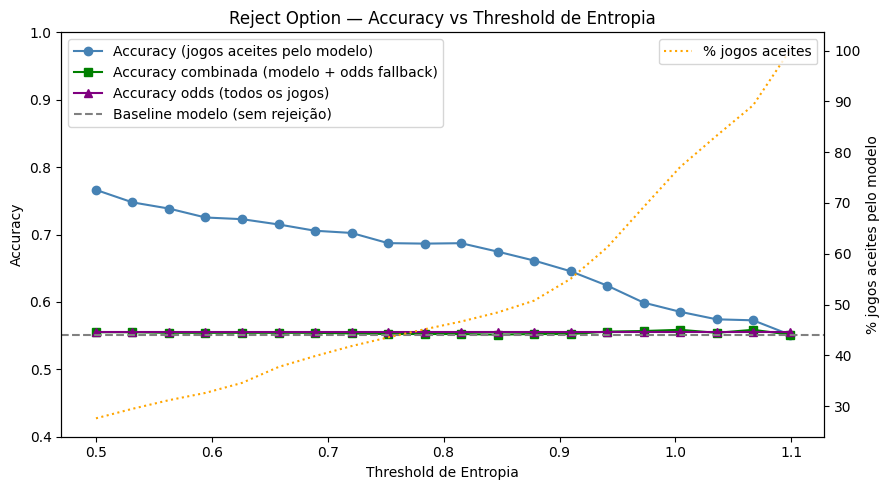

In [126]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(results_df['threshold'], results_df['acc_confident'],
         marker='o', color='steelblue', label='Accuracy (jogos aceites pelo modelo)')
ax1.plot(results_df['threshold'], results_df['acc_combined'],
         marker='s', color='green', label='Accuracy combinada (modelo + odds fallback)')
ax1.plot(results_df['threshold'], results_df['acc_odds_all'],
         marker='^', color='purple', label='Accuracy odds (todos os jogos)')
ax1.axhline(accuracy_score(y_te, y_pred_full), color='gray',
            linestyle='--', label='Baseline modelo (sem rejeição)')
ax1.set_xlabel("Threshold de Entropia")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.4, 1.0)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(results_df['threshold'], results_df['pct_confident'],
         color='orange', linestyle=':', label='% jogos aceites')
ax2.set_ylabel("% jogos aceites pelo modelo")
ax2.legend(loc='upper right')

plt.title("Reject Option — Accuracy vs Threshold de Entropia")
plt.tight_layout()
plt.show()